# Titanic - Survival Prediction with KNN 
This notebook analysis the famous Titanic dataset und uses **K-Nearest Neigbors (KNN)** algorithms to estimate passengers chance of survival

In [41]:
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import numpy as np 
import seaborn as sns

## Data loading and perform inital inspection

In [42]:
df = pd.read_csv("Titanic-Dataset.csv")

In [43]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [44]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [45]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [47]:
df.duplicated().sum()

0

In [48]:
print(f"Min Age: {df["Age"].min()}\nMean Age: {df["Age"].mean()}\nMax Age: {df["Age"].max()}\nMedian Age: {df["Age"].median()}")

Min Age: 0.42
Mean Age: 29.69911764705882
Max Age: 80.0
Median Age: 28.0


## Exploratory data analysis

### Age distribution of passengers

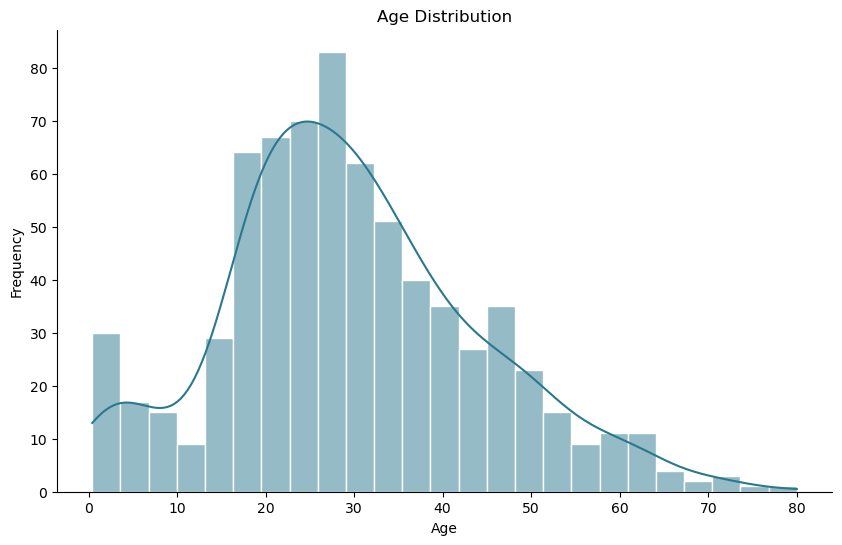

In [49]:
fig, ax = plt.subplots(figsize=(10,6))

ax= sns.histplot(df["Age"], bins=25, color="#2A788EFF", edgecolor="white", kde=True)

ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

## Data cleaning & feature engineering

### Imputation of age based on title

In [50]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

df["Title"] = df["Title"].replace(["Lady", "Countess", "Mme"], "Mrs")
df["Title"] = df["Title"].replace(["Ms","Mlle"], "Miss")
df["Title"] = df["Title"].replace(["Sir", "Don", "Major", "Col", "Capt", "Rev", "Jonkheer", "Dr"], "Mr")

df["Age"] = df["Age"].fillna(df.groupby("Title")["Age"].transform("mean"))

df["Age"] = df["Age"].astype("int")

In [51]:
df.groupby("Title")["Age"].mean()

Title
Master     4.425000
Miss      21.664865
Mr        33.003717
Mrs       35.757812
Name: Age, dtype: float64

In [52]:
df["Age"].isna().sum()

0

In [53]:
df.loc[df["Fare"] == 512.329200, "Name"]

258                      Ward, Miss. Anna
679    Cardeza, Mr. Thomas Drake Martinez
737                Lesurer, Mr. Gustave J
Name: Name, dtype: object

In [54]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [55]:
# Fill missing embarked values with the port that embarked most passengers
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].value_counts().idxmax())

In [56]:
#mapping sex to a number
dict = {
    "male": 1,
    "female": 0
}

df["Sex"] = df["Sex"].map(dict)

In [57]:
#dropping unnessesary columns
df = df.drop(df[["Cabin", "Ticket"]], axis=1)

### Correlation analysis

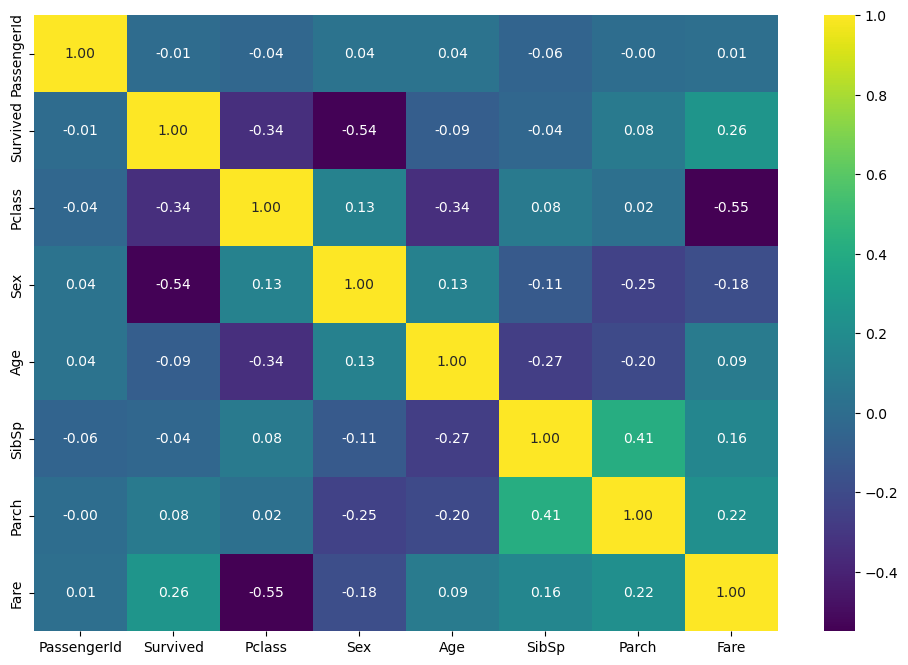

In [58]:
fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(df.select_dtypes(include="number").corr(), ax=ax, cmap="viridis", annot=True, fmt='.2f');

We can see that the Pclass and the sex of the passengers has the most impact on the survival of a passenger

In [59]:
df.loc[df["Fare"] == 512.329200, "Name"]

258                      Ward, Miss. Anna
679    Cardeza, Mr. Thomas Drake Martinez
737                Lesurer, Mr. Gustave J
Name: Name, dtype: object

## Visualisation of survival factors

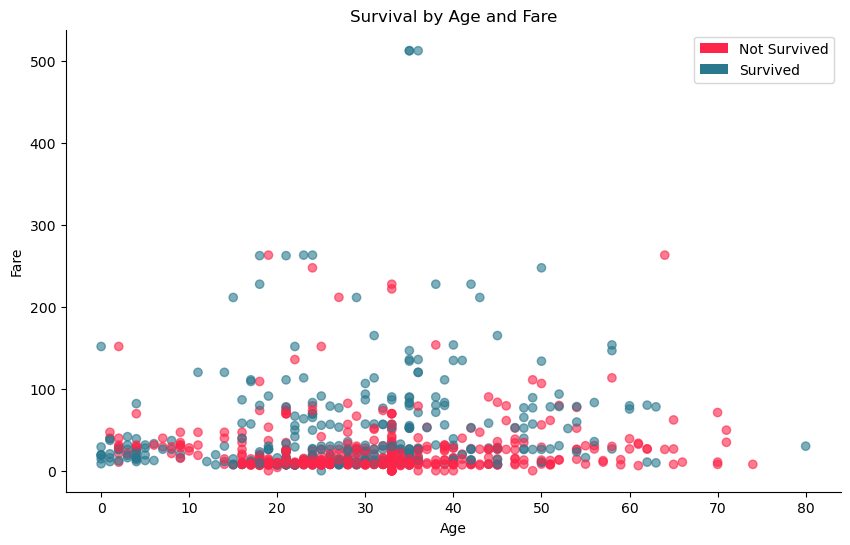

In [60]:
fig, ax = plt.subplots(figsize=(10,6))

colors = df["Survived"].map({0: "#FD2549FF", 1: "#2A788EFF"})
scatter = ax.scatter(df["Age"], df["Fare"], c=colors, alpha=0.6)

ax.set_title("Survival by Age and Fare")
ax.set_xlabel("Age")
ax.set_ylabel("Fare")

legend_elements = [Patch(facecolor="#FD2549FF", label="Not Survived"),
                   Patch(facecolor="#2A788EFF", label="Survived")]
ax.legend(handles=legend_elements)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

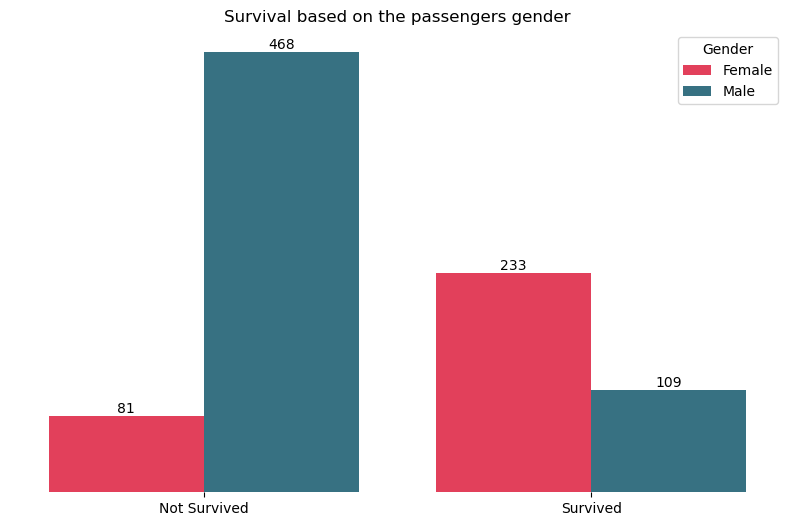

In [61]:
fig, ax = plt.subplots(figsize=(10,6))

ax = sns.countplot(x="Survived", hue="Sex", data=df, palette=["#FD2549FF","#2A788EFF"])

ax.set_title("Survival based on the passengers gender")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Survived", "Survived"])
ax.legend(title='Gender', loc='upper right', labels=['Female', 'Male'])
ax.set_xlabel("")

ax.axes.get_yaxis().set_visible(False)

ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for container in ax.containers:
    ax.bar_label(container)




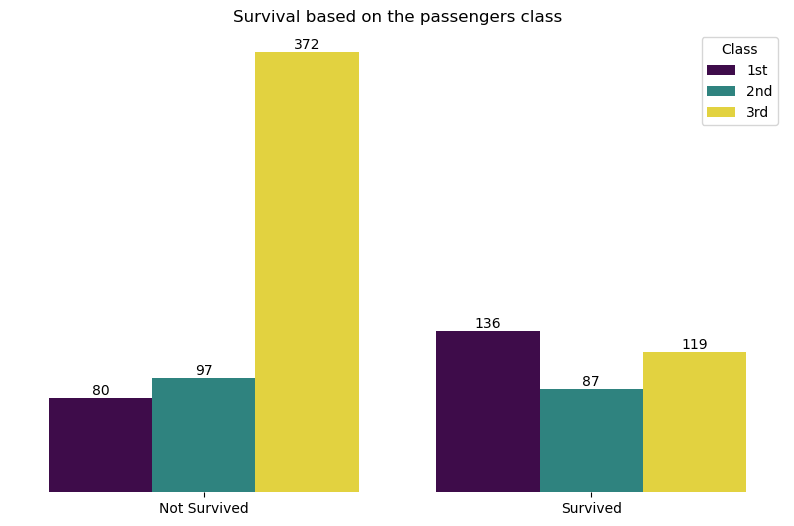

In [62]:
fig, ax = plt.subplots(figsize=(10,6))

ax = sns.countplot(x="Survived", hue="Pclass", data=df, palette="viridis")

ax.set_title("Survival based on the passengers class")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Survived", "Survived"])
ax.legend(title='Class', loc='upper right', labels=['1st', '2nd', "3rd"])
ax.set_xlabel("")

ax.axes.get_yaxis().set_visible(False)

ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for container in ax.containers:
    ax.bar_label(container)


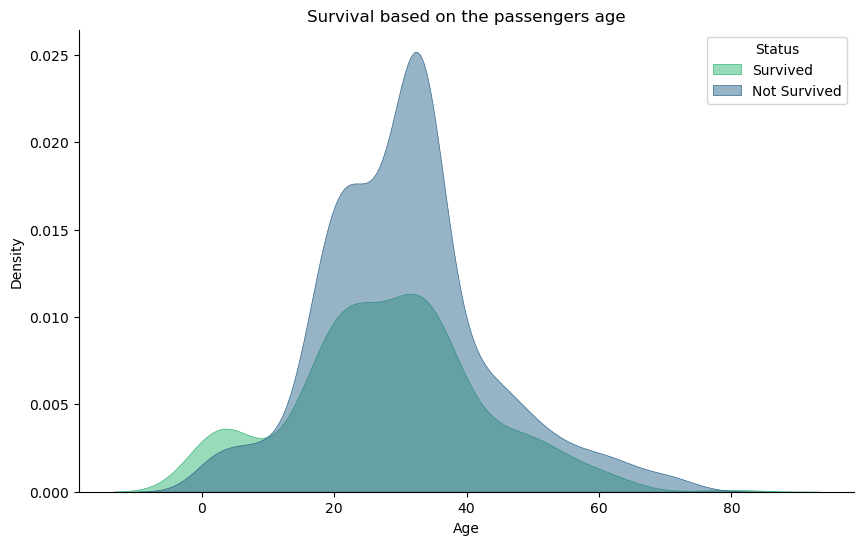

In [63]:
fig, ax = plt.subplots(figsize=(10,6))

ax = sns.kdeplot(x="Age", hue="Survived", data=df, fill=True, palette="viridis",alpha=.5, linewidth=0.5)

ax.set_title("Survival based on the passengers age")
ax.legend(['Survived', 'Not Survived'], title='Status')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



Children showed higher survival rates compared to adults.\
Young adults between the ages of 20 and 40 were more frequently represented among non-survivors.\
Overall, survival tended to decrease with increasing age.

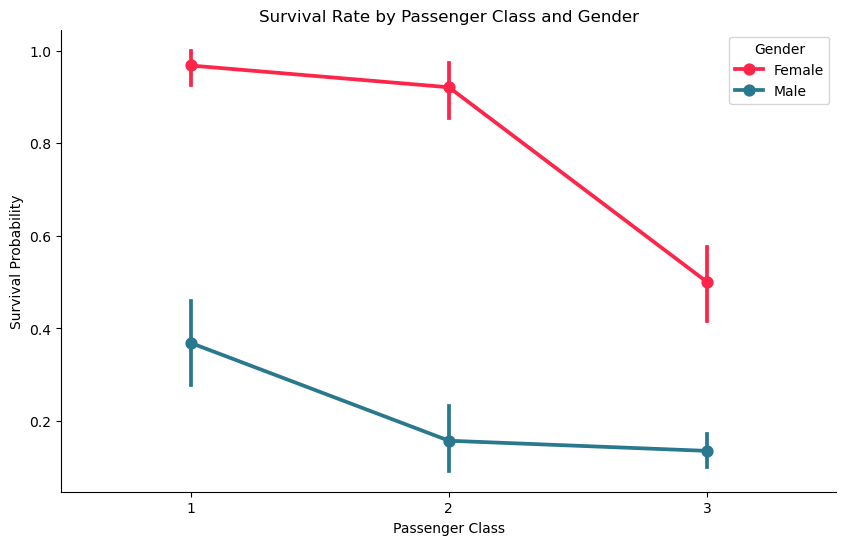

In [64]:
fig, ax = plt.subplots(figsize=(10,6))

ax = sns.pointplot(x="Pclass", y="Survived", palette=["#FD2549FF","#2A788EFF"],hue="Sex", data=df)


ax.set_title("Survival Rate by Passenger Class and Gender")
ax.set_ylabel("Survival Probability")
ax.set_xlabel("Passenger Class")

L = ax.legend()
L.get_texts()[0].set_text("Female")
L.get_texts()[1].set_text("Male")
ax.get_legend().set_title("Gender")



ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



Women in total had a greater chacne of survival than men. The chance of surviving woman in first and second class was nearly the same but dropped steep in thrid class.


### Influence of family size

In [65]:
df["Family_size"] = df[["SibSp", "Parch"]].sum(axis=1) +1

In [66]:
df["Family_size"].value_counts()

Family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

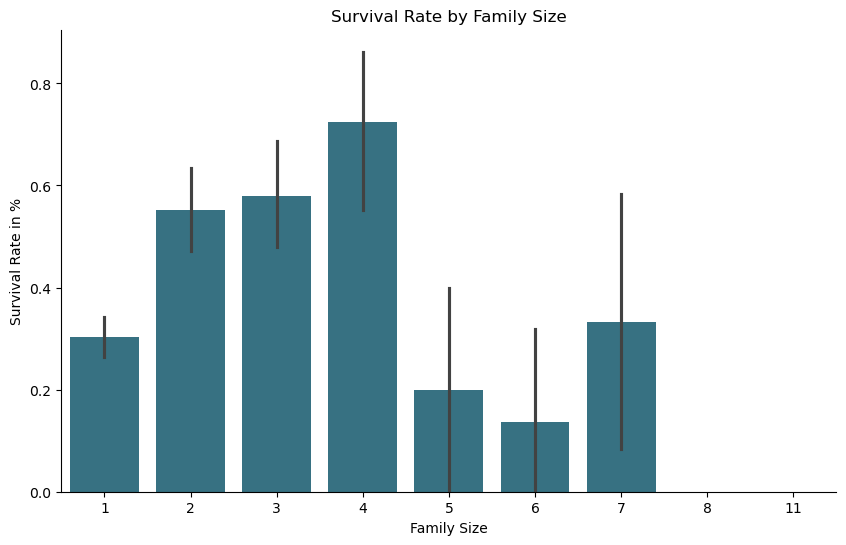

In [67]:
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(x="Family_size", y="Survived", data=df, 
            errorbar="ci",color="#2A788EFF", legend=False)

ax.set_title("Survival Rate by Family Size")
ax.set_ylabel("Survival Rate in %")
ax.set_xlabel("Family Size")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

Families with 2,3 or 4 members onboard had a greater chance of survival, than people going alone or in bigger families with 5 or more members onboard. 

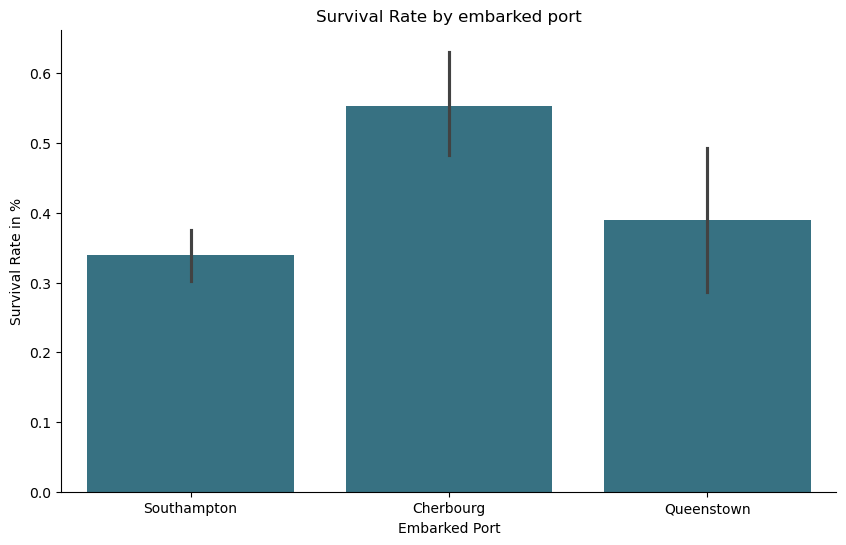

In [68]:
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(x="Embarked", y="Survived", data=df, 
            errorbar="ci",color="#2A788EFF", legend=False)

ax.set_title("Survival Rate by embarked port")
ax.set_ylabel("Survival Rate in %")
ax.set_xlabel("Embarked Port")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Southampton","Cherbourg","Queenstown"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

As the port of embarkation also plays a role I will add it to the KNN model

In [69]:
# Creating dummie values using one hot encoding
embarked_dummies = pd.get_dummies(df["Embarked"], prefix="Embarked",dtype=int)
df = pd.concat([df, embarked_dummies], axis=1)

In [70]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family_size,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22,1,0,7.2500,S,Mr,2,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38,1,0,71.2833,C,Mrs,2,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26,0,0,7.9250,S,Miss,1,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,1,0,53.1000,S,Mrs,2,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35,0,0,8.0500,S,Mr,1,0,0,1


## Machine Learning: K-Nearest Neighbors (KNN)

In [71]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Embarked', 'Title', 'Family_size', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [73]:
X = df[["Pclass", "Sex", "Fare", "Age", "Family_size", "Embarked_C",
       "Embarked_Q", "Embarked_S"]]
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=78923)

In [74]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print(knn.score(X_test_scaled, y_test))

0.8340807174887892


### Hyperparameter tuning: Finding the optimal k

In [76]:
X = df[["Pclass", "Sex", "Fare", "Age", "Family_size", "Embarked_C",
       "Embarked_Q", "Embarked_S"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=78923)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scores = []
ns = []

y_pred_15 = ""

for i in range(1,101):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled,y_train)
    if i == 15:
       y_pred_15 = knn.predict(X_test_scaled)
    s = knn.score(X_test_scaled, y_test)
    ns.append(i)
    scores.append(s)

Max score: 0.8475336322869955
Neighbors: [15, 16]


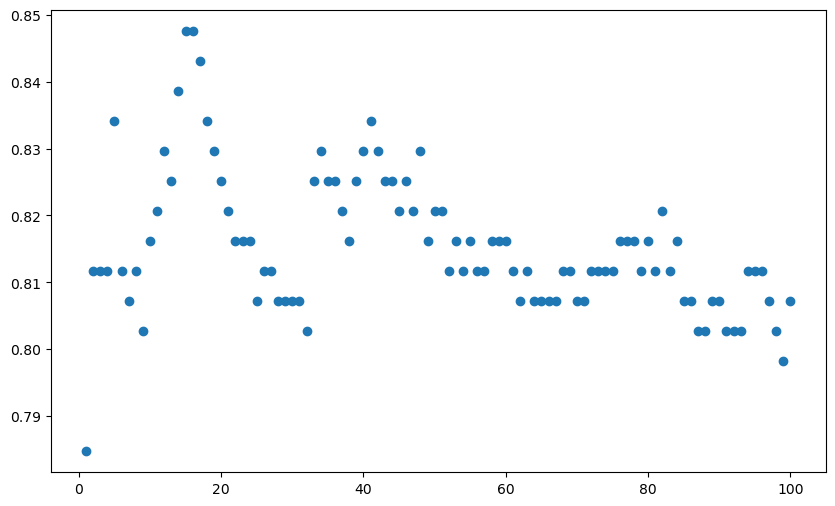

In [77]:
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(ns, scores)

max_score = max(scores)
best_neighbors = [ns[i] for i, s in enumerate(scores) if s == max_score]

print("Max score:", max_score)
print("Neighbors:", best_neighbors)

In [78]:
person = [[1, 1, 260, 23, 4, False, False, True]] #"Pclass", "Sex", "Fare", "Age", "Family_size", "Embarked_C", "Embarked_Q", "Embarked_S"

person_scaled = scaler.transform(person)

knn.predict(person_scaled)


c:\Users\devpo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

## Model Evaluation using a confusion matrix

In [79]:
from sklearn.metrics import confusion_matrix

In [80]:
cm = confusion_matrix(y_test, y_pred_15)

Text(0.5, 36.72222222222221, 'Predicted value')

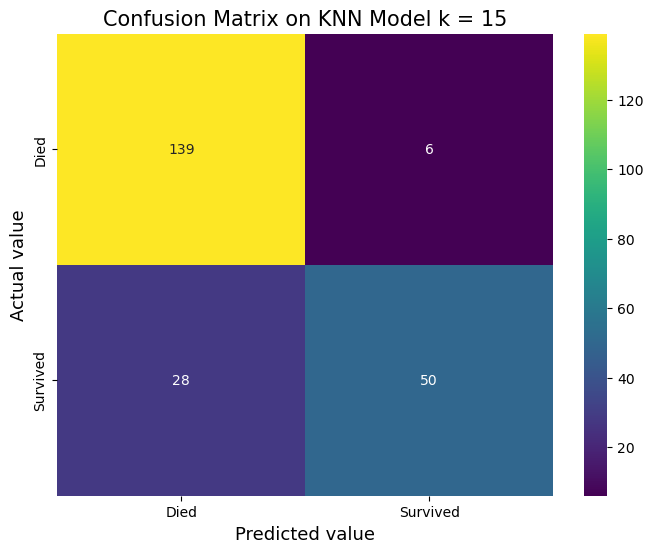

In [81]:

fig, ax = plt.subplots(figsize=(8,6))

ax = sns.heatmap(cm, annot=True, fmt="g", xticklabels=["Died", "Survived"],yticklabels=["Died", "Survived"], cmap="viridis")

ax.set_title("Confusion Matrix on KNN Model k = 15", fontsize=15)
ax.set_ylabel("Actual value", fontsize=13)
ax.set_xlabel("Predicted value", fontsize=13)

